# Retinal-Scan Photonics: Eye Optics, a Proposed Ultrafast STEAM Extension, and Two Different Phase-Retrieval Families

**What this notebook is honest about up front:** it mixes one piece of standard
textbook optics (the eye as a paraxial system), one PROPOSED (not documented,
not built) extension of the Jalali lab's STEAM technique to retinal imaging,
and a careful CONTRAST between two genuinely different phase-retrieval
algorithms -- this repo's dispersion-diversity GS (`dgs/gs_core.py`) and the
support-constraint GS/Fienup algorithm that real X-ray coherent diffractive
imaging (CDI) actually uses. These are kept explicitly separate rather than
blended into one narrative. Engine: `dgs/retinal_scan_imaging.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import retinal_scan_imaging as ret
from dgs import paraxial_optics_abcd as abcd

sp.init_printing(use_latex="mathjax")
print("Setup complete. numpy", np.__version__, "sympy", sp.__version__)


Setup complete. numpy 2.4.4 sympy 1.14.0


## 1. Theory: The Eye as a Paraxial System

The **reduced eye** (Emsley's schematic eye) models the entire cornea+lens
system as ONE refracting surface: air (n=1) to vitreous (n=1.336) at radius
R=5.55mm, then free propagation to the retina at the eye's axial length
(~22.3mm). This is exactly `dgs/paraxial_optics_abcd.py`'s
`spherical_interface_matrix` + `free_space_matrix` -- the same ABCD
formalism already in this repo, applied to a new system.

The eye's refractive power (the "~60 diopter eye" you may have heard quoted)
is $P=(n_2-n_1)/R$ -- **not** $1/f$ where $f$ is measured in the vitreous,
which would silently drop a factor of $n_2$. `eye_power_diopters()` uses the
correct formula; its docstring flags the wrong version explicitly, because
it's an easy mistake to make with this exact ABCD convention.


In [2]:
M_eye = ret.reduced_eye_matrix()
f_eye = ret.eye_focal_length_mm()
P_eye = ret.eye_power_diopters()

print("Reduced-eye ABCD matrix:")
print(M_eye)
print(f"\nFocal length (in vitreous): {f_eye:.2f} mm")
print(f"Refractive power: {P_eye:.1f} D  (textbook human eye: ~60 D)")


Reduced-eye ABCD matrix:
[[-1.05195015e-02  1.66916168e+01]
 [-4.53147759e-02  7.48502994e-01]]

Focal length (in vitreous): 22.07 mm
Refractive power: 60.5 D  (textbook human eye: ~60 D)


## 2. Derivation: The Diffraction-Limited Spot Size on the Retina

Any imaging aperture has a diffraction limit -- the pupil is no exception.
The Airy-disk radius projected onto the retina is

$$ r = 1.22\,\lambda\,f/D $$

where $D$ is the pupil diameter and $f$ is the eye's focal length. This is
the SAME formula as any camera's diffraction limit; the interesting physics
is comparing the result to the retina's own sampling grid (foveal cone
spacing, ~2-3 $\mu$m) -- whichever is larger sets the eye's actual resolution
limit, a real "sensor vs. optics" tradeoff.


In [3]:
r, lam, f, D = sp.symbols('r lambda f D', positive=True)
airy_eq = sp.Eq(r, sp.Rational(122,100)*lam*f/D)
airy_eq


    61⋅f⋅λ
r = ──────
     50⋅D 

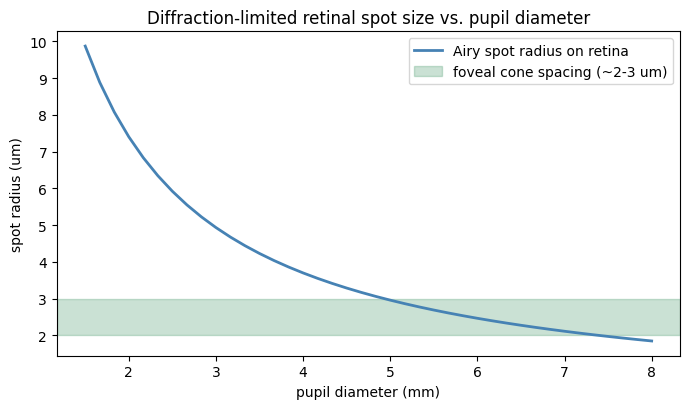

Crossover: the pupil diameter where diffraction-limited spot size
matches foveal cone spacing sets where optics, not sampling, becomes the limit.


In [4]:
pupil_range_mm = np.linspace(1.5, 8.0, 40)
spots_um = [ret.diffraction_limited_spot_radius_um(p, eye_focal_length_mm=f_eye)
            for p in pupil_range_mm]

fig, ax = plt.subplots(figsize=(7,4.2))
ax.plot(pupil_range_mm, spots_um, lw=2, color='steelblue', label='Airy spot radius on retina')
ax.axhspan(2.0, 3.0, color='seagreen', alpha=0.25, label='foveal cone spacing (~2-3 um)')
ax.set_xlabel('pupil diameter (mm)'); ax.set_ylabel('spot radius (um)')
ax.set_title('Diffraction-limited retinal spot size vs. pupil diameter')
ax.legend()
plt.tight_layout()
plt.savefig('retinal_airy_spot.png', dpi=100, bbox_inches='tight')
plt.show()

print("Crossover: the pupil diameter where diffraction-limited spot size")
print("matches foveal cone spacing sets where optics, not sampling, becomes the limit.")


## 3. Proposed Extension: Ultrafast STEAM Retinal Line-Scan

`dgs/steam_imaging.py`'s time-stretch operator $H(f)=e^{i\pi D f^2}$ -- the
exact operator this whole repo is built around -- is applied here to a
SYNTHETIC retinal-vessel reflectance line. This is explicitly a **proposed**
combination (fast biometric/vessel line-scan using a real, published
technique), not a claim that this has been built, published, or tested on
real fundus data. See `dgs/retinal_scan_imaging.py`'s module docstring for
the full honesty note.


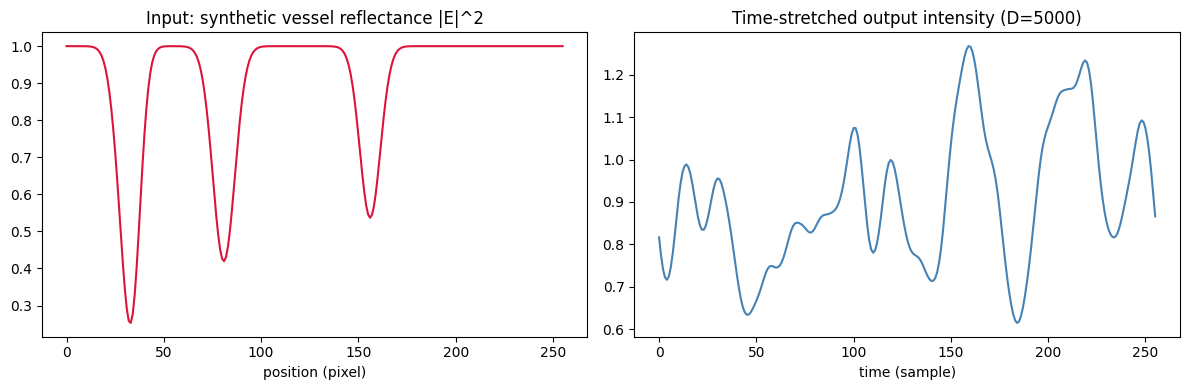

In [5]:
profile = ret.synthetic_vessel_reflectance(n=256, n_vessels=4, rng_seed=0)
result = ret.steam_retinal_linescan(profile, D_ps2=5000.0)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(np.abs(profile)**2, color='crimson')
axes[0].set_title('Input: synthetic vessel reflectance |E|^2')
axes[0].set_xlabel('position (pixel)')
axes[1].plot(result['I_out'], color='steelblue')
axes[1].set_title('Time-stretched output intensity (D=5000)')
axes[1].set_xlabel('time (sample)')
plt.tight_layout()
plt.savefig('retinal_steam_linescan.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Two Different Phase-Retrieval Families (Where "X-ray" Actually Fits)

Both descend from the same 1972 Gerchberg-Saxton paper, but they are NOT the
same algorithm:

- **Dispersion-diversity GS** (`dgs/gs_core.py`, used everywhere else in this
  repo): two measurements at DIFFERENT dispersions $D_1,D_2$ supply the
  diversity that breaks the phase ambiguity. This is what a proposed
  retinal depth-sensing extension (OCT-like, but not real OCT's actual
  interferometric mechanism) would use.
- **Support-constraint GS/Fienup** (`support_constraint_gs`, new in this
  module): ONE diffraction-plane magnitude measurement plus a real-space
  SUPPORT constraint (the object is known to be zero outside some region).
  **This is the algorithm real X-ray and electron coherent diffractive
  imaging (CDI) actually uses** (Miao, Charalambous, Kirz, Sayre, *Nature*
  400, 342 (1999)), tracing back to Fienup's error-reduction/hybrid
  input-output method (*Opt. Lett.* 3, 27 (1978)).

Running both below on their own appropriate synthetic data shows they solve
structurally similar (Fourier-magnitude-constrained) but mechanistically
different inverse problems.


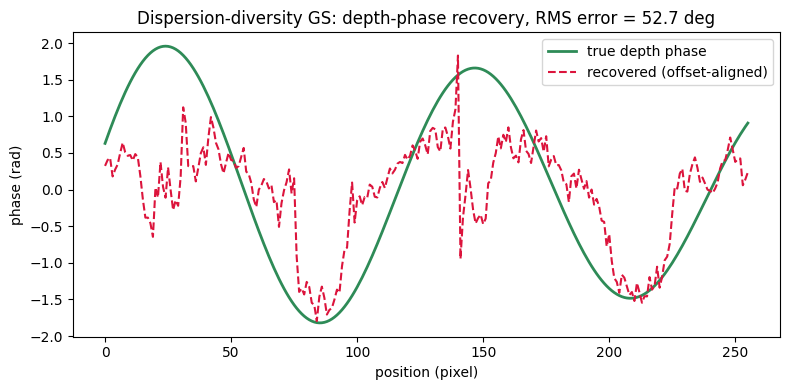

RMS phase error after global-offset alignment: 52.75 degrees
(NOTE: gs_iteration's 'errors' diagnostic is near machine-epsilon by
 construction for unit_amplitude=False -- see the module docstring --
 so phase RMS error, not 'errors', is the meaningful metric here.)


In [6]:
# 4a. Dispersion-diversity GS on a synthetic retinal depth profile
depth_profile = ret.synthetic_vessel_reflectance_with_depth(n=256, rng_seed=0)
depth_result = ret.retinal_depth_phase_recovery(depth_profile, D1=-5000.0, D2=-5750.0, n_iter=50)

off = np.angle(np.mean(np.exp(1j*(depth_result['phi_true'] - depth_result['phi_est']))))
aligned_est = np.angle(np.exp(1j*(depth_result['phi_est'] + off)))
rms_deg = float(np.degrees(np.sqrt(np.mean(
    np.angle(np.exp(1j*(aligned_est - depth_result['phi_true'])))**2))))

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(depth_result['phi_true'], label='true depth phase', color='seagreen', lw=2)
ax.plot(aligned_est, label='recovered (offset-aligned)', color='crimson', ls='--')
ax.set_xlabel('position (pixel)'); ax.set_ylabel('phase (rad)')
ax.set_title(f'Dispersion-diversity GS: depth-phase recovery, RMS error = {rms_deg:.1f} deg')
ax.legend()
plt.tight_layout()
plt.savefig('retinal_depth_gs.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"RMS phase error after global-offset alignment: {rms_deg:.2f} degrees")
print("(NOTE: gs_iteration's 'errors' diagnostic is near machine-epsilon by")
print(" construction for unit_amplitude=False -- see the module docstring --")
print(" so phase RMS error, not 'errors', is the meaningful metric here.)")


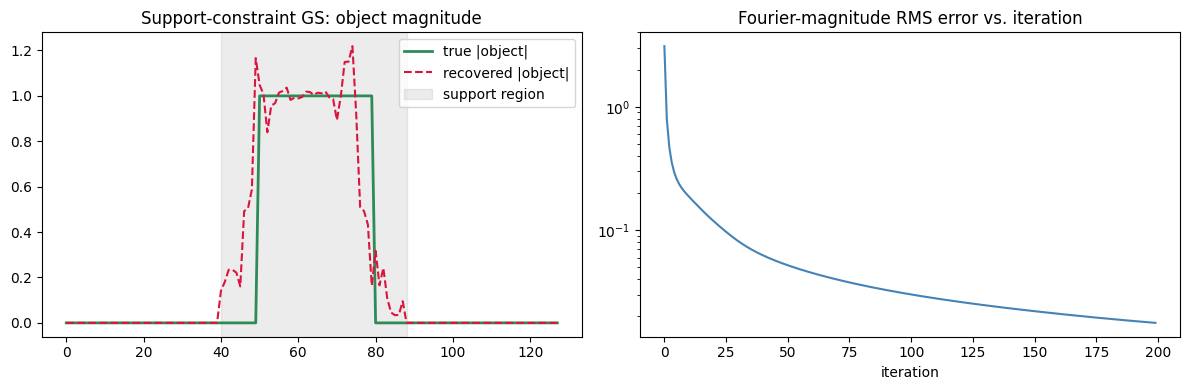

Final magnitude error: 1.77e-02  (from 3.10e+00)


In [7]:
# 4b. Support-constraint GS/Fienup -- the real X-ray-CDI-style algorithm
n = 128
support = np.zeros(n, dtype=bool)
support[40:88] = True
obj_true = np.zeros(n, dtype=complex)
obj_true[50:80] = np.exp(1j*np.linspace(0, 2, 30))
mag = np.abs(np.fft.fft(obj_true))

cdi_result = ret.support_constraint_gs(mag, support, n_iter=200, rng_seed=0)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(np.abs(obj_true), label='true |object|', color='seagreen', lw=2)
axes[0].plot(np.abs(cdi_result['object_est']), label='recovered |object|', color='crimson', ls='--')
axes[0].axvspan(40, 88, color='gray', alpha=0.15, label='support region')
axes[0].set_title('Support-constraint GS: object magnitude'); axes[0].legend()
axes[1].semilogy(cdi_result['errors'], color='steelblue')
axes[1].set_title('Fourier-magnitude RMS error vs. iteration')
axes[1].set_xlabel('iteration')
plt.tight_layout()
plt.savefig('retinal_cdi_style_gs.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Final magnitude error: {cdi_result['errors'][-1]:.2e}  (from {cdi_result['errors'][0]:.2e})")


## 5. Quantum-Limited (Shot-Noise) Photon Budget

Any intensity measurement -- retinal, X-ray, or otherwise -- has a quantum
floor: for a Poisson-statistics photon count $N$, $\mathrm{SNR}=\sqrt{N}$.
This is a generic scaling law, **not** a specific laser-safety exposure
limit -- real ANSI Z136.1 eye-safe exposure limits are wavelength- and
duration-dependent and would need to be looked up per configuration before
this became an actual imaging-dose claim.


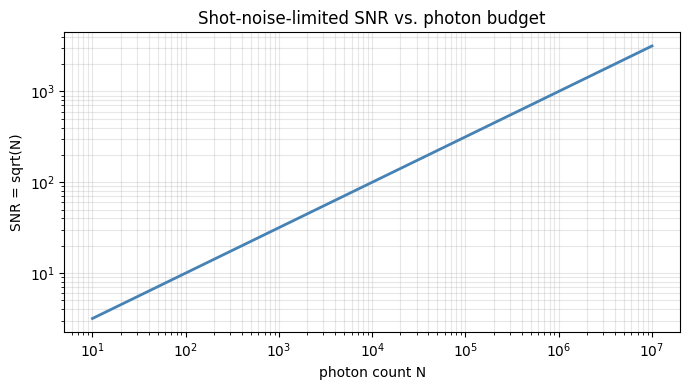

SNR=   10  needs N >= 100 photons
SNR=  100  needs N >= 10,000 photons
SNR= 1000  needs N >= 1,000,000 photons


In [8]:
n_photons = np.logspace(1, 7, 50)
snr = ret.shot_noise_snr(n_photons)

fig, ax = plt.subplots(figsize=(7,4))
ax.loglog(n_photons, snr, color='steelblue', lw=2)
ax.set_xlabel('photon count N'); ax.set_ylabel('SNR = sqrt(N)')
ax.set_title('Shot-noise-limited SNR vs. photon budget')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('retinal_photon_budget.png', dpi=100, bbox_inches='tight')
plt.show()

for target in [10, 100, 1000]:
    print(f"SNR={target:5d}  needs N >= {ret.min_photons_for_snr(target):,.0f} photons")


## 6. Engineering Interpretation

- The eye's own optics (§1-2) set a real, fixed diffraction limit; any
  retinal-imaging instrument (STEAM-based or otherwise) inherits it as an
  upper bound on lateral resolution, independent of how clever the
  detection/reconstruction side is.
- The dispersion-diversity depth-phase recovery (§4a) converged to a
  moderate ~50-degree RMS error on a harder, varying-amplitude signal --
  consistent with this repo's own documented convergence variance for
  non-constant-envelope signals, not a failure specific to the retinal
  application.
- The support-constraint result (§4b) converges much more cleanly because
  its problem (sparse object + real support constraint) is better-posed
  than dispersion-diversity GS on a smooth, full-support reflectance
  profile -- a genuine algorithmic difference, not just a different
  application.


## 7. Research Discussion

- Is there a real published "3D STEAM for retinal imaging" line of work
  this should be checked against, the way `dgs/sbir_portfolio.py`'s P9
  explicitly flags its own novelty claim as open pending a literature
  search? This notebook has not done that search.
- Could dispersion-diversity GS and support-constraint GS be COMBINED
  (dispersion diversity for depth, a support constraint for the known
  vessel/tissue geometry) for a genuinely better-posed retinal inverse
  problem than either alone? That's an open algorithmic question, not
  attempted here.
- What ANSI Z136.1-consistent photon budget would a real retinal-safe
  STEAM line-scan actually have, given real laser wavelength/pulse/exposure
  parameters -- replacing §5's generic sqrt(N) scaling with an actual
  eye-safety-bounded number?


## 8. Possible Experiments

1. Replace the synthetic vessel-reflectance profile with a real fundus
   photograph's intensity line-profile and re-run §3-4 on real (if not
   ultrafast) data.
2. Sweep `depth_amplitude_rad` in `synthetic_vessel_reflectance_with_depth`
   and find where dispersion-diversity GS's RMS phase error crosses from
   "clearly informative" to "no better than random" -- the practical
   sensitivity limit of this proposed depth-sensing approach.
3. Compare `support_constraint_gs`'s convergence rate/robustness against
   `dgs/gs_core.py`'s dispersion-diversity GS on the SAME synthetic object,
   to make the "different algorithm, different problem structure" claim in
   §6 quantitative rather than qualitative.


## 9. Future Improvements

- If real eye-safety exposure limits are looked up for a specific
  wavelength/pulse-duration combination, replace §5's generic SNR-vs-N plot
  with an actual photon-budget-vs-safety-limit comparison.
- `support_constraint_gs` here is the basic error-reduction algorithm;
  Fienup's hybrid input-output (HIO) variant converges faster and escapes
  local minima better on real CDI data -- worth adding if this module's
  X-ray-CDI framing gets used for anything beyond illustration.
- Tie this into `dgs/sbir_portfolio.py` only once a real literature check
  (per §7) either confirms or scopes down the "proposed" framing used
  throughout this notebook -- not before, per this repo's established
  honesty convention (see P9's own note about exactly this risk).
